## From TT optimized models, can simulate and visualize different spiking neural datasets

* need to match these w the parameters in real-life experiments

In [3]:
TT_NODE = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"

node_sim_data = "/scratch/gpfs/ad2002/content/datasets/dt/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"

# currently have heldin_50_heldout_10_obs_noise_pseudoPoisson_dispersion_1.0_seed_0.h5

In [76]:
from ctd.task_modeling.simulator.neural_simulator import NeuralDataSimulator
import pickle
import numpy as np
import matplotlib.pyplot as plt

# always runs with seed=0
def simulate(tt_model_path="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True",
             tt_dataset_path="/scratch/gpfs/ad2002/content/datasets/dt",
             tt_run_tag="20250407_PC_NODE_grid_final",
             tune_name="max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True",
             
             embed_dict={
                 "fr_scaling": 0.5,  # Scaling factor for firing rates
                 "rect_func": "softplus"  # Nonlinearity for rectification (options: "exp", "sigmoid", "softplus")
             },
             noise_dict={
                 "obs_noise": "poisson",  # Observation noise model (options: "poisson", "pseudoPoisson")
                 "dispersion": 0.1  # Dispersion parameter for pseudo-Poisson noise
             },
             neuron_dict={
                 "n_neurons_heldin": 300,
                 "n_neurons_heldout": 50,
             },
             trim_inds=None,
            ):
    
    """Simulate a spiking dataset from the latents of a task-trained model
    
    Returns:
        data (np.ndarray): the spiking dataset (n_trials, timesteps, total_neurons)
        inputs (np.ndarray): TT model inputs, correspond to the data
        activity (np.ndarray): rectified neural rates
        latents (np.ndarray): TT model latents
    """
    
    # load model
    with open(tt_model_path + "/model.pkl", "rb") as f:
        task_trained_model = pickle.load(f)
            
    # load datamodule
    with open(tt_model_path + "/datamodule_sim.pkl", "rb") as f:
        datamodule = pickle.load(f)
        datamodule.prepare_data()
        datamodule.setup()
    
    # create simulator object
    simulator = NeuralDataSimulator(neuron_dict, embed_dict, noise_dict, trim_inds)
    
    return simulator.simulate_neural_data(task_trained_model, datamodule, tt_run_tag, tune_name, tt_dataset_path, seed=0)



def raster_plot(spike_data, n_trials_to_plot=None, neurons_to_plot=3, figsize=(12, 18)):
    """
    Create raster plots of neuronal activity, with each trial as a separate subplot.
    
    Parameters:
    -----------
    spike_data : numpy.ndarray
        Array of shape (n_trials, timesteps, n_neurons) containing spike data
        where 1 indicates a spike and 0 indicates no spike.
    n_trials_to_plot : int or None
        Number of trials to plot. If None, all trials are plotted.
    neurons_to_plot : int
        Number of neurons to plot (from the beginning of the array)
    figsize : tuple
        Figure size (width, height) in inches
    """
    n_trials, timesteps, n_neurons = spike_data.shape
    
    # Handle how many trials to plot
    if n_trials_to_plot is None:
        n_trials_to_plot = n_trials
    else:
        n_trials_to_plot = min(n_trials_to_plot, n_trials)
    
    # Handle how many neurons to plot
    neurons_to_plot = min(neurons_to_plot, n_neurons)
    
    # Calculate layout for subplots
    n_cols = 1  # Max 3 columns
    n_rows = (n_trials_to_plot + n_cols - 1) // n_cols  # Ceiling division
    
    # Create figure and subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True, sharey=True)
    
    # Handle case where axes is not a 2D array
    if n_trials_to_plot == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Flatten for easier iteration
    axes_flat = axes.flatten()
    
    # Plot each trial
    for trial_idx in range(n_trials_to_plot):
        ax = axes_flat[trial_idx]
        
        # Extract data for the current trial, limited to the selected neurons
        trial_data = spike_data[trial_idx, :, :neurons_to_plot]
        
        # For each neuron
        for neuron_idx in range(neurons_to_plot):
            # Find the spike times for this neuron
            spike_times = np.where(trial_data[:, neuron_idx] > 0)[0]
            
            # Plot spikes as dots
            ax.scatter(spike_times, np.ones_like(spike_times) * neuron_idx, 
                      marker='.', color='black', s=10)
        
        # Set limits and labels
        ax.set_xlim(0, timesteps)
        ax.set_ylim(-0.5, neurons_to_plot - 0.5)
        #ax.set_title(f'Trial {trial_idx+1}')
    
    # Hide any unused subplots
    for idx in range(n_trials_to_plot, len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    # Set common labels
    fig.text(0.5, 0, 'Timesteps ($\Delta t=10~ms$)', ha='center', va='center', fontsize=12)
    fig.text(0.08, 0.5, 'Neurons', ha='center', va='center', rotation='vertical', fontsize=12)
    
    # plt.tight_layout(rect=[0.08, 0.05, 1, 0.95])  # Adjust layout to accommodate common labels
    
    return fig, axes


In [66]:
# softplus, poisson, dispersion=1.0 for best fit (overdispersion=0) in Luo et al

spike_data, inputs, activity, latents = simulate(
             embed_dict={
                 "fr_scaling": 1.0,  # mean to variance ratio for the embeddings
                 "rect_func": "softplus"  # Nonlinearity for rectification (options: "exp", "sigmoid", "softplus")
             },
             noise_dict={
                 "obs_noise": "poisson",  # Observation noise model (options: "poisson", "pseudoPoisson")
                 "dispersion": 1.0  # =1 for Poisson
             },
             neuron_dict={
                 "n_neurons_heldin": 300,
                 "n_neurons_heldout": 50,
             },)

(<Figure size 1200x300 with 3 Axes>,
 array([[<Axes: >],
        [<Axes: >],
        [<Axes: >]], dtype=object))

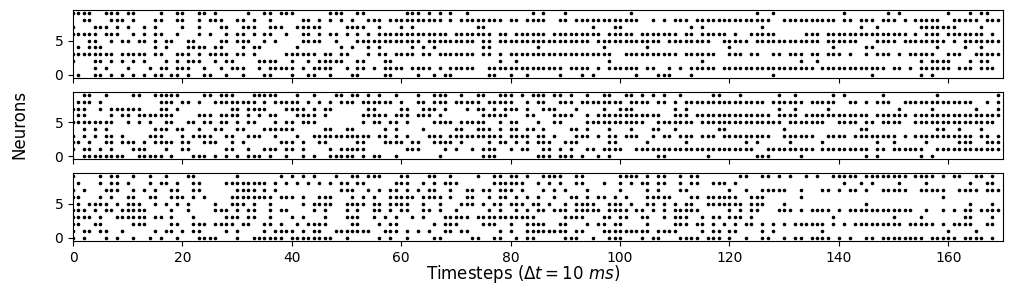

In [77]:
raster_plot(spike_data, n_trials_to_plot=3, neurons_to_plot=10, figsize=(12,3))#, plot_inputs=True)

# all neurons have the same sudden change for ONE trial
# it varies across trials

# ex below for 10 neurons from first 3 trials (as many trials as input trials in TT)